# Out of Sample Validation
This notebook runs the out-of-sample validation pipeline to benchmark EmbAlign's generalizability by evaluating the fitted production models on independently generated ground-truth labeled datasets.

In [ ]:
import pandas as pd
import os
import glob
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from aligner.config import PipelineConfig
from aligner.atlas import AtlasFactory
from aligner.matcher import SinkhornMatcher
from aligner.transformer import RigidTransformer
from aligner.engine import ModularAlignmentEngine
from aligner.oracle import DiagnosticLayer
from aligner.runner import ValidationRunner
from aligner.plot_utils import *

In [ ]:
# Load Data
oos_pts = pd.read_csv('data/oos_registered_pts.csv')
oos_pts.head()

,embryo_id,time_idx,cell_name,x_um,y_um,z_um,nuclear_diameter_um,valid,n_cells_frame,source_file,canonical_time
0,OOS_SPIMA_P4,7,P2,37.2552,17.8695,19.50,4.2237,1,6,t007-nuclei,19.5
1,OOS_SPIMA_P4,7,ABar,14.7288,14.9454,19.50,2.7075,1,6,t007-nuclei,19.5
2,OOS_SPIMA_P4,7,ABal,15.0537,17.2197,23.25,2.7075,1,6,t007-nuclei,19.5
3,OOS_SPIMA_P4,7,EMS,27.8331,11.1549,25.50,4.4403,1,6,t007-nuclei,19.5
4,OOS_SPIMA_P4,7,ABpr,25.4505,18.7359,17.25,2.7075,1,6,t007-nuclei,19.5


In [9]:
# Load EmbAlign models
MODEL_DIR = "production_models"

master_atlas = joblib.load(os.path.join(MODEL_DIR, 'master_gp_atlas.pkl'))
master_slice_db = joblib.load(os.path.join(MODEL_DIR, 'master_slice_db.pkl'))
oracle = DiagnosticLayer(model_path=os.path.join(MODEL_DIR, 'production_oracle.pkl'))

DiagnosticLayer: Loaded model from production_models/production_oracle.pkl


In [14]:
# Configure pipeline
config = PipelineConfig.v3_0_production()
production_engine = ModularAlignmentEngine(
    config=config, 
    atlas=master_atlas, 
    slice_db=master_slice_db,
    coarse_matcher=SinkhornMatcher(epsilon=config.epsilon_coarse),
    icp_matcher=SinkhornMatcher(epsilon=config.epsilon_refine),
    transformer=RigidTransformer()
)
validator = ValidationRunner(engine=production_engine, oracle=oracle)

# Run alignment
val_frames_df, val_diags_df = validator.evaluate_orthogonal_dataset(oos_pts, verbose=True)


Starting Orthogonal Validation on 187 frames...


 39%|███▊      | 72/187 [00:35<01:45,  1.09it/s]

[Atlas Gap] No biological slices found for N=66 cells.


 90%|████████▉ | 168/187 [02:03<00:17,  1.06it/s]

[Atlas Gap] No biological slices found for N=79 cells.


100%|██████████| 187/187 [02:49<00:00,  1.10it/s]


----------------------------------------
RUN COMPLETE
Positional Accuracy:  96.2%
Set Overlap (Acc):    98.3%
Perfect Set Matches:  150/185
Mean Oracle Confidence: 81.1%
----------------------------------------



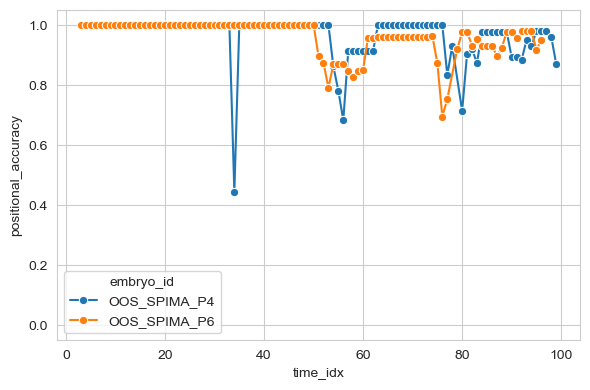

In [26]:
# Visualize
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))

sns.lineplot(
    data=val_frames_df,
    x='time_idx',
    y='positional_accuracy',
    hue='embryo_id',
    marker='o'
)

plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [27]:
# Cache
val_frames_df.to_csv("data/oos_aligned_frame_results.csv", index = False)
val_diags_df.to_csv("data/oos_aligned_cell_results.csv", index = False)